# Runs all Tox21 experiments with the full dataset!

1 output tasks 
Tox21 AUC-ROC KernelSVM: 0.822 GC: 0.829


Regression, 1,000 ish compounds, Random split, RMSE

CM and CM eigh require 3D structure - i don't think we need to run these anyways

rdkit featurisation does not work with classifier and i have no idea why - I think I need to add in a normalising transformer for that data!

Weave doesnt have a classification mode

Smiles to images + chemception does not work, but it should

Use tdaf-tf2p7h2             C:\Users\ella_\.conda\envs\tdaf-tf2p7h2

In [23]:
import sys
sys.path.append(r"C:\Users\ella_\Documents\GitHub\graphs_and_topology_for_chemistry")
sys.path.append(r"C:\Users\ella_\Documents\GitHub\icosahedron_projection")

import deepchem as dc
#from deepchem.feat import SmilesToImage

import tensorflow as tf
import os
import sys
import rdkit
import h5py
import helper_functions as h

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.tri
import rdkit.Chem as Chem
import rdkit.Chem.AllChem as AllChem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors
import mpl_toolkits.mplot3d
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from collections import Counter

print("TensorFlow version: " + tf.__version__)

# topology stuff
from gtda.plotting import plot_point_cloud
from gtda.homology import VietorisRipsPersistence
from gtda.plotting import plot_diagram
from gtda.diagrams import PersistenceEntropy
from gtda.diagrams import NumberOfPoints
from gtda.diagrams import Amplitude
from sklearn.pipeline import make_union, Pipeline

# fixc this at some point
sys.path.append(r"C:\Users\ella_\Documents\GitHub\graphs_and_topology_for_chemistry")
sys.path.append(r"C:\Users\ella_\Documents\GitHub\icosahedron_projection")

import projection
#from projection.molecule import Molecule
#from projection.pdbmolecule import PDBMolecule
#from projection.mol2molecule import Mol2Molecule

import helper_functions as h
loaders, classification_datasets, regression_datasets, metric_types = h.deepchem_dataset_dictionaries()

# change THIS

dataset_name='bbbp'

data_dir=r'F:\Nextcloud\science\Datasets\topol_datasets'
results_dir=r"F:\Nextcloud\science\results\topology_and_graphs\d_" + dataset_name
test_file=dataset_name + '.csv'
data_file_name=dataset_name + '_topological_features.hdf5'
loader = loaders[dataset_name]
make_dataset=False # whether to recalc the dataset

print(f"DeepChem version: {dc.__version__}")

############################### settings for all experiments #################

#Tox21 AUC-ROC KernelSVM: 0.822 GC: 0.829
best_con = 0.822
best_graph = 0.829

num_repeats= 3
num_epochs =500


metric1 = dc.metrics.Metric(dc.metrics.balanced_accuracy_score)
metric2 = dc.metrics.Metric(dc.metrics.prc_auc_score)
metric3 = dc.metrics.Metric(dc.metrics.roc_auc_score)
metric4 = dc.metrics.Metric(dc.metrics.f1_score)
#metric3 = dc.metrics.Metric(dc.metrics.mae_score)
metrics = [metric1, metric2, metric3, metric4]
selected_metric = 2 #which metric to use for callback
metric_selector=selected_metric
metric_labels = ['balanced_accuracy_score',
                 'prc_auc_score',
                 'roc_auc_score',
                 'f1_score']
#'roc_auc_score': 0.7074633658540642, 'f1_score': 0.343048783618714
Splitter = dc.splits.RandomSplitter()

# setting up the splitters for the task
#Splitter_Object_tf = dc.splits.SingletaskStratifiedSplitter()
#Splitter_Object_pca = dc.splits.SingletaskStratifiedSplitter()

split_fraction=[0.1, 0.1, 0.8]
n_classes=2


TensorFlow version: 2.7.0
DeepChem version: 2.5.0


In [2]:
hdf5_file_name=dataset_name + '_topological_features.hdf5'
fh = h5py.File(os.path.join(data_dir,hdf5_file_name), 'r+')
num_of_rows, num_of_molecules = h.basic_info_hdf5_dataset(fh, label='molID')

num_of_ rows is:	2036
num_of_molecules is:	 2036
num_of_augments is:	1


In [3]:
fh.keys()

<KeysViewHDF5 ['PCA_1', 'PCA_10', 'PCA_11', 'PCA_12', 'PCA_13', 'PCA_14', 'PCA_15', 'PCA_16', 'PCA_17', 'PCA_18', 'PCA_2', 'PCA_3', 'PCA_4', 'PCA_5', 'PCA_6', 'PCA_7', 'PCA_8', 'PCA_9', 'SMILES', 'bottle_1', 'bottle_2', 'bottle_3', 'landsc_1', 'landsc_2', 'landsc_3', 'molID', 'name', 'no_p_1', 'no_p_2', 'no_p_3', 'p_np', 'pers_S_1', 'pers_S_2', 'pers_S_3', 'pers_img_1', 'pers_img_2', 'pers_img_3', 'wasser_1', 'wasser_2', 'wasser_3']>

In [4]:
egg=np.array(fh['p_np'])

In [38]:
2000-sum(egg)

447

In [29]:
fh.close()

In [2]:
tasks, datasets, transformers = loader(
    shard_size=2000,
    featurizer=h.My_Dummy_Featurizer(None),
    splitter=None) # not shuffled

In [3]:
datasets[0].X[179]

'Nc1ccc(cc1)[S](=O)(=O)c2ccc(N)cc2'

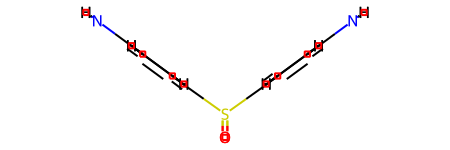

In [16]:
mol, coords = h.coord_creator('Nc1ccc(cc1)[S](=O)(=O)c2ccc(N)cc2')
mol

In [20]:
mol, coords = h.coord_creator(datasets[0].X[2050])
mol

IndexError: index 2050 is out of bounds for axis 0 with size 2050

In [96]:
range(len(dataset.y) - len(Failures))

range(0, 2038)

In [97]:
len(new_y)

2038

In [105]:
len(dataset.y)

2050

In [106]:
range(len(dataset.y))

range(0, 2050)

In [111]:
dataset=datasets[0]

Failures = [59, 61, 391, 614, 642, 645, 646, 647, 648, 649, 685, 1998]
new_y = np.zeros(len(dataset.y) - len(Failures)).reshape((-1, 1))
count=0
for i in range(len(dataset.y)):
    #print(f"i: {i}")
    if i in Failures:
        print(f"Failure: i is {i}, dataset.y[i] is {dataset.y[i]}" )
    else:
    #    print(f"count: {count}")        
    #    print(dataset.y[i])
        new_y[count]=dataset.y[i]
        count = count + 1
    #print('------')

Failure: i is 59, dataset.y[i] is [1.]
Failure: i is 61, dataset.y[i] is [1.]
Failure: i is 391, dataset.y[i] is [1.]
Failure: i is 614, dataset.y[i] is [1.]
Failure: i is 642, dataset.y[i] is [0.]
Failure: i is 645, dataset.y[i] is [1.]
Failure: i is 646, dataset.y[i] is [0.]
Failure: i is 647, dataset.y[i] is [0.]
Failure: i is 648, dataset.y[i] is [0.]
Failure: i is 649, dataset.y[i] is [1.]
Failure: i is 685, dataset.y[i] is [1.]
Failure: i is 1998, dataset.y[i] is [1.]


In [113]:
Failures = [59, 61, 391, 614, 642, 645, 646, 647, 648, 649, 685, 1998]

def remove_specific_points(y_values, specific_points):
    """removes specific lines in the .csv file
    presumably because rdkit fails on them
    specific_points : lines to remove, 0 indexed!!!!"""
    Failures = specific_points
    new_y = np.zeros(len(y_values) - len(Failures)).reshape((-1, 1))
    count=0
    for i in range(len(y_values)):
        #print(f"i: {i}")
        if i in Failures:
            print(f"Failure: i is {i}, y_values[i] is {y_values[i]}" )
        else:
        #    print(f"count: {count}")        
        #    print(dataset.y[i])
            new_y[count]=y_values[i]
            count = count + 1
    return 



remove_specific_points(y_values=dataset.y, specific_points=Failures)

Failure: i is 59, y_values[i] is [1.]
Failure: i is 61, y_values[i] is [1.]
Failure: i is 391, y_values[i] is [1.]
Failure: i is 614, y_values[i] is [1.]
Failure: i is 642, y_values[i] is [0.]
Failure: i is 645, y_values[i] is [1.]
Failure: i is 646, y_values[i] is [0.]
Failure: i is 647, y_values[i] is [0.]
Failure: i is 648, y_values[i] is [0.]
Failure: i is 649, y_values[i] is [1.]
Failure: i is 685, y_values[i] is [1.]
Failure: i is 1998, y_values[i] is [1.]


array([[1.],
       [1.],
       [1.],
       ...,
       [1.],
       [1.],
       [1.]])

In [121]:
from csv import reader
dataset_name='bbbp'
save_dir=r'F:\Nextcloud\science\Datasets\topol_datasets'
with open(os.path.join(save_dir,dataset_name + '_SMILES.csv'), 'r') as read_obj:
    # pass the file object to reader() to get the reader object
    csv_reader = reader(read_obj)
    # Pass reader object to list() to get a list of lists
    SMILES_list = list(csv_reader)

In [122]:
SMILES_list

[['ï»¿[Cl].CC(C)NCC(O)COc1cccc2ccccc12'],
 ['C(=O)(OC(C)(C)C)CCCc1ccc(cc1)N(CCCl)CCCl'],
 ['c12c3c(N4CCN(C)CC4)c(F)cc1c(c(C(O)=O)cn2C(C)CO3)=O'],
 ['C1CCN(CC1)Cc1cccc(c1)OCCCNC(=O)C'],
 ['Cc1onc(c2ccccc2Cl)c1C(=O)N[C@H]3[C@H]4SC(C)(C)[C@@H](N4C3=O)C(O)=O'],
 ['CCN1CCN(C(=O)N[C@@H](C(=O)N[C@H]2[C@H]3SCC(=C(N3C2=O)C(O)=O)CSc4nnnn4C)c5ccc(O)cc5)C(=O)C1=O'],
 ['CN(C)[C@H]1[C@@H]2C[C@H]3C(=C(O)c4c(O)cccc4[C@@]3(C)O)C(=O)[C@]2(O)C(=O)\\C(=C(/O)NCN5CCCC5)C1=O'],
 ['Cn1c2CCC(Cn3ccnc3C)C(=O)c2c4ccccc14'],
 ['COc1ccc(cc1)[C@@H]2Sc3ccccc3N(CCN(C)C)C(=O)[C@@H]2OC(C)=O'],
 ['NC(N)=NC(=O)c1nc(Cl)c(N)nc1N'],
 ['OCC(C)(O)c1onc(c2ncn3c2CN(C)C(c4c3cccc4Cl)=O)n1'],
 ['CC1=CN([C@H]2C[C@H](F)[C@@H](CO)O2)C(=O)NC1=O'],
 ['C(Cl)Cl'],
 ['C1N(C(CC2CCCCC12)C(NC(C)(C)C)=O)CC(C(Cc1ccccc1)NC(C(NC(c1nc2c(cccc2)cc1)=O)CC(N)=O)=O)O'],
 ['CCC(=O)C(CC(C)N(C)C)(c1ccccc1)c2ccccc2'],
 ['CCN1N=NN(CCN2CCC(CC2)(COC)N(C(=O)CC)c3ccccc3)C1=O'],
 ['CN(C)C(=O)C(CCN1CCC(O)(CC1)c1ccc(Cl)cc1)(c1ccccc1)c1ccccc1'],
 ['CN1C2CCC1CC(C2)O

In [125]:
help(dc.trans.CoulombFitTransformer)

Help on class CoulombFitTransformer in module deepchem.trans.transformers:

class CoulombFitTransformer(transformers.Transformer)
 |  CoulombFitTransformer(dataset: deepchem.data.datasets.Dataset)
 |  
 |  Performs randomization and binarization operations on batches of Coulomb Matrix features during fit.
 |  
 |  Examples
 |  --------
 |  >>> n_samples = 10
 |  >>> n_features = 3
 |  >>> n_tasks = 1
 |  >>> ids = np.arange(n_samples)
 |  >>> X = np.random.rand(n_samples, n_features, n_features)
 |  >>> y = np.zeros((n_samples, n_tasks))
 |  >>> w = np.ones((n_samples, n_tasks))
 |  >>> dataset = dc.data.NumpyDataset(X, y, w, ids)
 |  >>> fit_transformers = [dc.trans.CoulombFitTransformer(dataset)]
 |  >>> model = dc.models.MultitaskFitTransformRegressor(n_tasks,
 |  ...    [n_features, n_features], batch_size=n_samples, fit_transformers=fit_transformers, n_evals=1)
 |  >>> print(model.n_features)
 |  12
 |  
 |  Method resolution order:
 |      CoulombFitTransformer
 |      transforme

In [124]:
def remove_specific_points_str(y_values, specific_points):
    """removes specific lines in the .csv file
    presumably because rdkit fails on them
    specific_points : lines to remove, 0 indexed!!!!"""
    Failures = specific_points
    new_y = []
    count=0
    for i in range(len(y_values)):
        #print(f"i: {i}")
        if i in Failures:
            print(f"Failure: i is {i}, y_values[i] is {y_values[i]}" )
        else:
        #    print(f"count: {count}")        
        #    print(dataset.y[i])
            new_y.append(y_values[i])
            count = count + 1
    return new_y
remove_specific_points_str(y_values=SMILES_list, specific_points=Failures)

Failure: i is 59, y_values[i] is ['O=N([O-])C1=C(CN=C1NCCSCc2ncccc2)Cc3ccccc3']
Failure: i is 61, y_values[i] is ['c1(nc(NC(N)=[NH2])sc1)CSCCNC(=[NH]C#N)NC']
Failure: i is 391, y_values[i] is ['Cc1nc(sc1)\\[NH]=C(\\N)N']
Failure: i is 614, y_values[i] is ['s1cc(CSCCN\\C(NC)=[NH]\\C#N)nc1\\[NH]=C(\\N)N']
Failure: i is 642, y_values[i] is ['c1c(c(ncc1)CSCCN\\C(=[NH]\\C#N)NCC)Br']
Failure: i is 645, y_values[i] is ['n1c(csc1\\[NH]=C(\\N)N)c1ccccc1']
Failure: i is 646, y_values[i] is ['n1c(csc1\\[NH]=C(\\N)N)c1cccc(c1)N']
Failure: i is 647, y_values[i] is ['n1c(csc1\\[NH]=C(\\N)N)c1cccc(c1)NC(C)=O']
Failure: i is 648, y_values[i] is ['n1c(csc1\\[NH]=C(\\N)N)c1cccc(c1)N\\C(NC)=[NH]\\C#N']
Failure: i is 649, y_values[i] is ['s1cc(nc1\\[NH]=C(\\N)N)C']
Failure: i is 685, y_values[i] is ['c1(cc(N\\C(=[NH]\\c2cccc(c2)CC)C)ccc1)CC']
Failure: i is 1998, y_values[i] is ['[C@@H]3(C1=CC=C(Cl)C=C1)[C@H]2CC[C@@H](C2)C34CCC(=N4)N5CCOCC5']


[['ï»¿[Cl].CC(C)NCC(O)COc1cccc2ccccc12'],
 ['C(=O)(OC(C)(C)C)CCCc1ccc(cc1)N(CCCl)CCCl'],
 ['c12c3c(N4CCN(C)CC4)c(F)cc1c(c(C(O)=O)cn2C(C)CO3)=O'],
 ['C1CCN(CC1)Cc1cccc(c1)OCCCNC(=O)C'],
 ['Cc1onc(c2ccccc2Cl)c1C(=O)N[C@H]3[C@H]4SC(C)(C)[C@@H](N4C3=O)C(O)=O'],
 ['CCN1CCN(C(=O)N[C@@H](C(=O)N[C@H]2[C@H]3SCC(=C(N3C2=O)C(O)=O)CSc4nnnn4C)c5ccc(O)cc5)C(=O)C1=O'],
 ['CN(C)[C@H]1[C@@H]2C[C@H]3C(=C(O)c4c(O)cccc4[C@@]3(C)O)C(=O)[C@]2(O)C(=O)\\C(=C(/O)NCN5CCCC5)C1=O'],
 ['Cn1c2CCC(Cn3ccnc3C)C(=O)c2c4ccccc14'],
 ['COc1ccc(cc1)[C@@H]2Sc3ccccc3N(CCN(C)C)C(=O)[C@@H]2OC(C)=O'],
 ['NC(N)=NC(=O)c1nc(Cl)c(N)nc1N'],
 ['OCC(C)(O)c1onc(c2ncn3c2CN(C)C(c4c3cccc4Cl)=O)n1'],
 ['CC1=CN([C@H]2C[C@H](F)[C@@H](CO)O2)C(=O)NC1=O'],
 ['C(Cl)Cl'],
 ['C1N(C(CC2CCCCC12)C(NC(C)(C)C)=O)CC(C(Cc1ccccc1)NC(C(NC(c1nc2c(cccc2)cc1)=O)CC(N)=O)=O)O'],
 ['CCC(=O)C(CC(C)N(C)C)(c1ccccc1)c2ccccc2'],
 ['CCN1N=NN(CCN2CCC(CC2)(COC)N(C(=O)CC)c3ccccc3)C1=O'],
 ['CN(C)C(=O)C(CCN1CCC(O)(CC1)c1ccc(Cl)cc1)(c1ccccc1)c1ccccc1'],
 ['CN1C2CCC1CC(C2)O

In [82]:
np.zeros(len(dataset.y) - len(Failures))[np.newaxis]

array([[0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
egg= [x for xdataset.y Failures = [59, 61, 391, 614, 642, 645, 646, 647, 648, 649, 685, 1998]

In [40]:
datasets[0].X

array([[0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       ...,
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]])

In [30]:
tasks, datasets, transformers = loader(
    shard_size=2000,
    featurizer=h.My_Dummy_Featurizer(None),
    splitter=None) # not shuffled

In [46]:
datasets[0].X

array(['[Cl].CC(C)NCC(O)COc1cccc2ccccc12',
       'C(=O)(OC(C)(C)C)CCCc1ccc(cc1)N(CCCl)CCCl',
       'c12c3c(N4CCN(C)CC4)c(F)cc1c(c(C(O)=O)cn2C(C)CO3)=O', ...,
       'C1=C(C(=C(C=C1C(NCC(N(CC)CC)=O)=O)OC)OC)OC',
       'C3=C(C2(C1=CC=CC=C1)C(N(C(C(Cl)(Cl)Cl)O)CN2)=O)C=CC=C3',
       'O=[P](O)(OCC(Cl)(Cl)Cl)O'], dtype='<U400')

In [42]:
datasets[0].X

array(['[Cl].CC(C)NCC(O)COc1cccc2ccccc12',
       'C(=O)(OC(C)(C)C)CCCc1ccc(cc1)N(CCCl)CCCl',
       'c12c3c(N4CCN(C)CC4)c(F)cc1c(c(C(O)=O)cn2C(C)CO3)=O', ...,
       '[O+]1=N[N](C=C1[N-]C(NC2=CC=CC=C2)=O)C(CC3=CC=CC=C3)C',
       'C1=C(OC)C(=CC2=C1C(=[N+](C(=C2CC)C)[NH-])C3=CC=C(C(=C3)OC)OC)OC',
       '[N+](=NCC(=O)N[C@@H]([C@H](O)C1=CC=C([N+]([O-])=O)C=C1)CO)=[N-]'],
      dtype='<U400')

In [5]:
feature_name_list = ['pers_S_1', 'pers_S_2', 'pers_S_3',
                    'no_p_1', 'no_p_2', 'no_p_3',
                    'bottle_1', 'bottle_2', 'bottle_3',
                    'wasser_1', 'wasser_2', 'wasser_3',
                    'landsc_1', 'landsc_2', 'landsc_3',
                    'pers_img_1', 'pers_img_2', 'pers_img_3']

PCA_list = ['PCA_1', 'PCA_2', 'PCA_3',
           'PCA_4', 'PCA_5', 'PCA_6',
           'PCA_7', 'PCA_8', 'PCA_9',
           'PCA_10', 'PCA_11', 'PCA_12',
           'PCA_13', 'PCA_14', 'PCA_15',
           'PCA_16', 'PCA_17', 'PCA_18']

task_list = ['p_np']

## Functions

In [40]:
test_dataset

NameError: name 'test_dataset' is not defined

In [47]:
dataset.y

NameError: name 'dataset' is not defined

In [27]:
Chem.MolFromSmiles("O=N([O-])C1=C(CN=C1NCCSCc2ncccc2)Cc3ccccc3")

In [26]:
mol_orig = Chem.MolFromSmiles("O=N([O-])C1=C(CN=C1NCCSCc2ncccc2)Cc3ccccc3")
#mol_orig = Chem.AddHs(mol_orig)
status = AllChem.EmbedMolecule(mol_orig)
status = AllChem.UFFOptimizeMolecule(mol_orig)
egg = mol_orig.GetConformer()
rdkit.Chem.rdMolTransforms.CanonicalizeConformer(egg)
coords = egg.GetPositions()

ArgumentError: Python argument types in
    rdkit.Chem.rdDistGeom.EmbedMolecule(NoneType)
did not match C++ signature:
    EmbedMolecule(class RDKit::ROMol {lvalue} mol, struct RDKit::DGeomHelpers::EmbedParameters {lvalue} params)
    EmbedMolecule(class RDKit::ROMol {lvalue} mol, unsigned int maxAttempts=0, int randomSeed=-1, bool clearConfs=True, bool useRandomCoords=False, double boxSizeMult=2.0, bool randNegEig=True, unsigned int numZeroFail=1, class boost::python::dict {lvalue} coordMap={}, double forceTol=0.001, bool ignoreSmoothingFailures=False, bool enforceChirality=True, bool useExpTorsionAnglePrefs=True, bool useBasicKnowledge=True, bool printExpTorsionAngles=False, bool useSmallRingTorsions=False, bool useMacrocycleTorsions=False, unsigned int ETversion=1)

# Load data


## Create topological datasets

We use Numpy datasets to create the two toplogical datasets and two transformers (used as the controls use them and they are supposed to improve training). The topological dataset is normalised in X and y, PCA is only normalised in y as PCA is a normalisation.

This sorts out the datasets, transformers and splitters for the task

In [ ]:
fh['SMILES']

In [11]:
## loading data from the hdf5 file
X_data = h.load_all_hdf5(
    fh,
    num_of_rows, 
    column_headers=feature_name_list)

PCA_X_data = h.load_all_hdf5(
    fh,
    num_of_rows, 
    column_headers=PCA_list)

y_data = h.load_all_hdf5(
    fh,
    num_of_rows, 
    column_headers=task_list)

SMILES_list = np.array(fh['SMILES'])

# making the datasets
topol_dataset = dc.data.DiskDataset.from_numpy(
    X_data, 
    y_data, 
    ids=SMILES_list)

pca_dataset = dc.data.DiskDataset.from_numpy(
    PCA_X_data, 
    y_data, 
    ids=SMILES_list)

# doing a transform on the data to make it easier for hte NN
# both y and x

transformers_tf = [
    dc.trans.BalancingTransformer(
        dataset=topol_dataset)]
# only y
transformers_pca = [
    dc.trans.BalancingTransformer(dataset=topol_dataset)]


topol_dataset = transformers_tf[0].transform(topol_dataset)



C:\Users\ella_\.conda\envs\tdaf-tf2p7h2\lib\site-packages\numpy\lib\format.py:363: UserWarning: metadata on a dtype may be saved or ignored, but will raise if saved when read. Use another form of storage.
  d['descr'] = dtype_to_descr(array.dtype)


In [60]:
topol_dataset.w

array([[10.],
       [10.],
       [10.],
       ...,
       [10.],
       [10.],
       [10.]], dtype=float32)

Text(0, 0.5, 'No.')

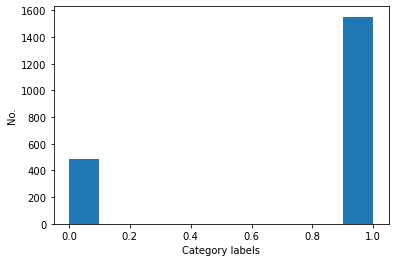

In [8]:
plt.hist(y_data)
plt.xlabel('Category labels')
plt.ylabel("No.")

# Training on the topological features

#### Topological features

In [70]:
def topol_classification_experiment(
        dataset,
        transformers,
        Splitter_Object,
        tasks,
        metrics,
        metric_selector,
        num_repeats=5,
        num_epochs=250,
        split_fraction=[0.8, 0.1, 0.1],
        patience=15,
        metric_labels=['balanced_accuracy_score',
                 'prc_auc_score',
                 'roc_auc_score',
                 'f1_score']):
    """runs repeated training with topol input features
    uses default multitask regressor class
    does splitting and transforming
    returns metrics

    dataset: overall original dataset, before splitting
    transformers: deepchem transformer
    Splitter_object: deepchem splitter
    num_epochs: num epochs if not early stopping
    metric_selector: whihc one to train wiht
    split fraction: train, val, test split as decimal
    patience: for early stopping
    metric_labels: add rmse here if you want it, do not add to metrics
    metrics: list of metrics"""

    ## in function

    out = []

    frac_train = split_fraction[0]
    frac_valid = split_fraction[1]
    frac_test = split_fraction[2]
    train_scores, validate_scores, test_scores = [], [], []
    print(f'Metric selected is {metric_labels[metric_selector]}')
    # transforms datasets wooo
    dataset = h.do_transform(transformers, dataset)
    for i in range(num_repeats):
        # make datasets
        train_dataset, valid_dataset, test_dataset = Splitter_Object.train_valid_test_split(
            dataset=dataset,
            frac_train=frac_train,
            frac_valid=frac_valid,
            frac_test=frac_test)
        print(f"Training with {len(train_dataset.y)} points")
        print(f"Validation with {len(valid_dataset.y)} points")
        print(f"Testing with {len(test_dataset.y)} points")
        print(f"Total dataset size: {len(train_dataset.y) + len(valid_dataset.y) + len(test_dataset.y)}")


        # for later
        datasets = [train_dataset, valid_dataset, test_dataset]
        # actual model here
        model = dc.models.MultitaskClassifier(
            n_tasks=len(tasks),
            n_features=len(train_dataset.X[3]),
            # layer_sizes=[1000,1000,500,20],
            # dropouts=0.2,
            # learning_rate=0.001,
            n_classes=n_classes,
            residual=True)
        callback = dc.models.ValidationCallback(
            valid_dataset,
            patience,
            metrics[metric_selector])
        # fit da model
        model.fit(train_dataset, nb_epoch=num_epochs, callbacks=callback)

        # little function to calc metrics on this data
        out.append(h.get_them_metrics(
            model,
            datasets,
            metrics,
            metric_labels,
            transformers))

    pd_out = pd.DataFrame(out, columns=['tr_bal_acc', 'tr_prc_auc', 'tr_roc_auc', 'tr_f1',
                                        'val_bal_acc', 'val_prc_auc', 'val_roc_auc', 'val_f1',
                                        'te_bal_acc', 'te_prc_auc', 'te_roc_auc', 'te_f1'])
    return pd_out

In [67]:
dataset=topol_dataset
transformers=transformers_tf
Splitter_Object=Splitter
tasks=task_list
metrics=metrics
metric_selector=selected_metric
num_repeats=3
num_epochs=num_epochs
split_fraction=split_fraction
patience=15
metric_labels=metric_labels
split_fraction=[0.8,0.1,0.1]
n_classes=2

In [68]:
    out=[]
    frac_train = split_fraction[0]
    frac_valid = split_fraction[1]
    frac_test = split_fraction[2]
    train_scores, validate_scores, test_scores = [], [], []
    print(f'Metric selected is {metric_labels[metric_selector]}')
    # transforms datasets wooo
    dataset = h.do_transform(transformers, dataset)
    for i in range(num_repeats):
        # make datasets
        train_dataset, valid_dataset, test_dataset = Splitter_Object.train_valid_test_split(
            dataset=dataset,
            frac_train=frac_train,
            frac_valid=frac_valid,
            frac_test=frac_test)
        print(f"Training with {len(train_dataset.y)} points")
        print(f"Validation with {len(valid_dataset.y)} points")
        print(f"Testing with {len(test_dataset.y)} points")
        print(f"Total dataset size: {len(train_dataset.y) + len(valid_dataset.y) + len(test_dataset.y)}")


        # for later
        datasets = [train_dataset, valid_dataset, test_dataset]
        # actual model here
        model = dc.models.MultitaskClassifier(
            n_tasks=len(tasks),
            n_features=len(train_dataset.X[3]),
            # layer_sizes=[1000,1000,500,20],
            # dropouts=0.2,
            # learning_rate=0.001,
            n_classes=n_classes,
            residual=True)
        callback = dc.models.ValidationCallback(
            valid_dataset,
            patience,
            metrics[metric_selector])
        # fit da model
        model.fit(train_dataset, nb_epoch=num_epochs, callbacks=callback)

        # little function to calc metrics on this data
        out.append(h.get_them_metrics(
            model,
            datasets,
            metrics,
            metric_labels,
            transformers))

Metric selected is roc_auc_score
Training with 1628 points
Validation with 204 points
Testing with 204 points
Total dataset size: 2036
Step 15 validation: roc_auc_score=0.697135
Step 30 validation: roc_auc_score=0.71457
Training with 1628 points
Validation with 204 points
Testing with 204 points
Total dataset size: 2036


C:\Users\ella_\.conda\envs\tdaf-tf2p7h2\lib\site-packages\numpy\lib\format.py:363: UserWarning: metadata on a dtype may be saved or ignored, but will raise if saved when read. Use another form of storage.
  d['descr'] = dtype_to_descr(array.dtype)


Step 15 validation: roc_auc_score=0.632386
Step 30 validation: roc_auc_score=0.683097
Training with 1628 points


C:\Users\ella_\.conda\envs\tdaf-tf2p7h2\lib\site-packages\numpy\lib\format.py:363: UserWarning: metadata on a dtype may be saved or ignored, but will raise if saved when read. Use another form of storage.
  d['descr'] = dtype_to_descr(array.dtype)


Validation with 204 points
Testing with 204 points
Total dataset size: 2036
Step 15 validation: roc_auc_score=0.619152
Step 30 validation: roc_auc_score=0.673775


(array([ 483.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
        1553.]),
 array([ 1.037037 ,  3.7333333,  6.42963  ,  9.125926 , 11.822222 ,
        14.518518 , 17.214815 , 19.911112 , 22.607407 , 25.303703 ,
        28.       ], dtype=float32),
 <BarContainer object of 10 artists>)

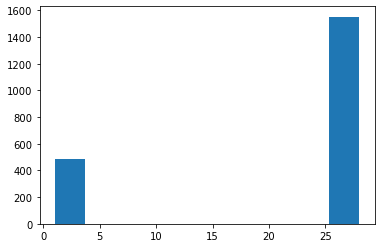

In [69]:
plt.hist(topol_dataset.w)

In [57]:
n_samples = 10
n_features = 3
n_tasks = 1
n_classes = 2
ids = np.arange(n_samples)
X = np.random.rand(n_samples, n_features)
y = np.random.randint(n_classes, size=(n_samples, n_tasks))
w = np.ones((n_samples, n_tasks))
dataset = dc.data.NumpyDataset(X, y, w, ids)
transformer = dc.trans.BalancingTransformer(dataset=dataset)
dataset = transformer.transform(dataset)

In [58]:
dataset.w

array([[ 1.11111111],
       [ 1.11111111],
       [ 1.11111111],
       [ 1.11111111],
       [ 1.11111111],
       [10.        ],
       [ 1.11111111],
       [ 1.11111111],
       [ 1.11111111],
       [ 1.11111111]])

In [12]:
%%time
output_metrics_tf=h.topol_classification_experiment(
    dataset=topol_dataset,
    transformers=transformers_tf,
    Splitter_Object=Splitter,
    tasks=task_list,
    metrics=metrics,
    metric_selector=selected_metric,
    num_repeats=num_repeats,
    num_epochs=num_epochs,
    split_fraction=split_fraction,
    patience=15,
    metric_labels=metric_labels
    )
output_metrics_tf

Metric selected is roc_auc_score
Training with 203 points
Validation with 204 points
Testing with 1629 points
Total dataset size: 2036
Step 15 validation: roc_auc_score=0.737001
Step 30 validation: roc_auc_score=0.749524
Step 45 validation: roc_auc_score=0.758719
Step 60 validation: roc_auc_score=0.751744
Step 75 validation: roc_auc_score=0.777901
Step 90 validation: roc_auc_score=0.778694
Step 105 validation: roc_auc_score=0.780913
Step 120 validation: roc_auc_score=0.780913
Step 135 validation: roc_auc_score=0.779645
Step 150 validation: roc_auc_score=0.780755
Step 165 validation: roc_auc_score=0.785193
Step 180 validation: roc_auc_score=0.785035
Step 195 validation: roc_auc_score=0.773304
Step 210 validation: roc_auc_score=0.784718
Step 225 validation: roc_auc_score=0.77267
Step 240 validation: roc_auc_score=0.77156
Step 255 validation: roc_auc_score=0.780913
Step 270 validation: roc_auc_score=0.76078
Step 285 validation: roc_auc_score=0.767597
Step 300 validation: roc_auc_score=0.7

C:\Users\ella_\.conda\envs\tdaf-tf2p7h2\lib\site-packages\numpy\lib\format.py:363: UserWarning: metadata on a dtype may be saved or ignored, but will raise if saved when read. Use another form of storage.
  d['descr'] = dtype_to_descr(array.dtype)


Training with 203 points
Validation with 204 points
Testing with 1629 points
Total dataset size: 2036
Step 15 validation: roc_auc_score=0.584008
Step 30 validation: roc_auc_score=0.663082
Step 45 validation: roc_auc_score=0.648659
Step 60 validation: roc_auc_score=0.651063
Step 75 validation: roc_auc_score=0.646761
Step 90 validation: roc_auc_score=0.654858
Step 105 validation: roc_auc_score=0.656123
Step 120 validation: roc_auc_score=0.648279
Step 135 validation: roc_auc_score=0.651189
Step 150 validation: roc_auc_score=0.658654
Step 165 validation: roc_auc_score=0.661943
Step 180 validation: roc_auc_score=0.664853
Step 195 validation: roc_auc_score=0.660931
Step 210 validation: roc_auc_score=0.653973
Step 225 validation: roc_auc_score=0.657389
Step 240 validation: roc_auc_score=0.657009
Step 255 validation: roc_auc_score=0.646635
Step 270 validation: roc_auc_score=0.664347
Step 285 validation: roc_auc_score=0.653846
Step 300 validation: roc_auc_score=0.66498
Step 315 validation: roc_

C:\Users\ella_\.conda\envs\tdaf-tf2p7h2\lib\site-packages\numpy\lib\format.py:363: UserWarning: metadata on a dtype may be saved or ignored, but will raise if saved when read. Use another form of storage.
  d['descr'] = dtype_to_descr(array.dtype)


Training with 203 points
Validation with 204 points
Testing with 1629 points
Total dataset size: 2036
Step 15 validation: roc_auc_score=0.592597
Step 30 validation: roc_auc_score=0.622727
Step 45 validation: roc_auc_score=0.602338
Step 60 validation: roc_auc_score=0.610779
Step 75 validation: roc_auc_score=0.593636
Step 90 validation: roc_auc_score=0.612078
Step 105 validation: roc_auc_score=0.615325
Step 120 validation: roc_auc_score=0.598312
Step 135 validation: roc_auc_score=0.621299
Step 150 validation: roc_auc_score=0.622338
Step 165 validation: roc_auc_score=0.618442
Step 180 validation: roc_auc_score=0.635714
Step 195 validation: roc_auc_score=0.63
Step 210 validation: roc_auc_score=0.617922
Step 225 validation: roc_auc_score=0.634935
Step 240 validation: roc_auc_score=0.640779
Step 255 validation: roc_auc_score=0.637403
Step 270 validation: roc_auc_score=0.645195
Step 285 validation: roc_auc_score=0.638182
Step 300 validation: roc_auc_score=0.643117
Step 315 validation: roc_auc

,tr_bal_acc,tr_prc_auc,tr_roc_auc,tr_f1,val_bal_acc,val_prc_auc,val_roc_auc,val_f1,te_bal_acc,te_prc_auc,te_roc_auc,te_f1
0,0.823739,0.965173,0.898497,0.864286,0.701649,0.916846,0.757609,0.787671,0.643500,0.824750,0.663357,0.798312
1,0.870171,0.985132,0.931257,0.911950,0.602986,0.828419,0.654068,0.790698,0.638030,0.827287,0.661826,0.817363
2,0.811195,0.963770,0.903899,0.846715,0.667403,0.816434,0.665974,0.767025,0.647251,0.831184,0.670621,0.757454


#### PCA of topological features

In [13]:
%%time
output_metrics_pca=h.topol_classification_experiment(
    dataset=pca_dataset,
    transformers=transformers_pca,
    Splitter_Object=Splitter,
    tasks=task_list,
    metrics=metrics,
    metric_selector=selected_metric,
    num_repeats=num_repeats,
    num_epochs=num_epochs,
    split_fraction=split_fraction,
    patience=15,
    metric_labels=metric_labels
    )
output_metrics_pca

Metric selected is roc_auc_score
Training with 203 points
Validation with 204 points
Testing with 1629 points
Total dataset size: 2036


C:\Users\ella_\.conda\envs\tdaf-tf2p7h2\lib\site-packages\numpy\lib\format.py:363: UserWarning: metadata on a dtype may be saved or ignored, but will raise if saved when read. Use another form of storage.
  d['descr'] = dtype_to_descr(array.dtype)


Step 15 validation: roc_auc_score=0.708961
Step 30 validation: roc_auc_score=0.665097
Step 45 validation: roc_auc_score=0.672468
Step 60 validation: roc_auc_score=0.662435
Step 75 validation: roc_auc_score=0.67039
Step 90 validation: roc_auc_score=0.684286
Step 105 validation: roc_auc_score=0.673799
Step 120 validation: roc_auc_score=0.674383
Step 135 validation: roc_auc_score=0.676623
Step 150 validation: roc_auc_score=0.671981
Step 165 validation: roc_auc_score=0.684286
Step 180 validation: roc_auc_score=0.681299
Step 195 validation: roc_auc_score=0.664935
Step 210 validation: roc_auc_score=0.660779
Step 225 validation: roc_auc_score=0.674805
Step 240 validation: roc_auc_score=0.667792
Step 255 validation: roc_auc_score=0.69026
Step 270 validation: roc_auc_score=0.67013
Step 285 validation: roc_auc_score=0.66211
Step 300 validation: roc_auc_score=0.681429
Step 315 validation: roc_auc_score=0.685065
Step 330 validation: roc_auc_score=0.672955
Step 345 validation: roc_auc_score=0.66737

C:\Users\ella_\.conda\envs\tdaf-tf2p7h2\lib\site-packages\numpy\lib\format.py:363: UserWarning: metadata on a dtype may be saved or ignored, but will raise if saved when read. Use another form of storage.
  d['descr'] = dtype_to_descr(array.dtype)


Training with 203 points
Validation with 204 points
Testing with 1629 points
Total dataset size: 2036
Step 15 validation: roc_auc_score=0.76115
Step 30 validation: roc_auc_score=0.738462
Step 45 validation: roc_auc_score=0.755089
Step 60 validation: roc_auc_score=0.765812
Step 75 validation: roc_auc_score=0.764103
Step 90 validation: roc_auc_score=0.750427
Step 105 validation: roc_auc_score=0.758508
Step 120 validation: roc_auc_score=0.768298
Step 135 validation: roc_auc_score=0.758664
Step 150 validation: roc_auc_score=0.754468
Step 165 validation: roc_auc_score=0.766744
Step 180 validation: roc_auc_score=0.763481
Step 195 validation: roc_auc_score=0.780575
Step 210 validation: roc_auc_score=0.736597
Step 225 validation: roc_auc_score=0.747164
Step 240 validation: roc_auc_score=0.754157
Step 255 validation: roc_auc_score=0.75711
Step 270 validation: roc_auc_score=0.74965
Step 285 validation: roc_auc_score=0.756954
Step 300 validation: roc_auc_score=0.757887
Step 315 validation: roc_au

C:\Users\ella_\.conda\envs\tdaf-tf2p7h2\lib\site-packages\numpy\lib\format.py:363: UserWarning: metadata on a dtype may be saved or ignored, but will raise if saved when read. Use another form of storage.
  d['descr'] = dtype_to_descr(array.dtype)


Training with 203 points
Validation with 204 points
Testing with 1629 points
Total dataset size: 2036
Step 15 validation: roc_auc_score=0.713542
Step 30 validation: roc_auc_score=0.692041
Step 45 validation: roc_auc_score=0.713942
Step 60 validation: roc_auc_score=0.728766
Step 75 validation: roc_auc_score=0.714343
Step 90 validation: roc_auc_score=0.725828
Step 105 validation: roc_auc_score=0.711405
Step 120 validation: roc_auc_score=0.729567
Step 135 validation: roc_auc_score=0.728499
Step 150 validation: roc_auc_score=0.723157
Step 165 validation: roc_auc_score=0.711806
Step 180 validation: roc_auc_score=0.727163
Step 195 validation: roc_auc_score=0.710604
Step 210 validation: roc_auc_score=0.717949
Step 225 validation: roc_auc_score=0.718616
Step 240 validation: roc_auc_score=0.724493
Step 255 validation: roc_auc_score=0.711405
Step 270 validation: roc_auc_score=0.723157
Step 285 validation: roc_auc_score=0.715678
Step 300 validation: roc_auc_score=0.717682
Step 315 validation: roc

,tr_bal_acc,tr_prc_auc,tr_roc_auc,tr_f1,val_bal_acc,val_prc_auc,val_roc_auc,val_f1,te_bal_acc,te_prc_auc,te_roc_auc,te_f1
0,0.791195,0.957139,0.885409,0.820896,0.632208,0.825872,0.688571,0.692308,0.621631,0.846889,0.670663,0.721026
1,0.771774,0.943600,0.851613,0.848276,0.669697,0.921171,0.743901,0.768166,0.607452,0.813804,0.647313,0.744577
2,0.762236,0.952284,0.857947,0.847458,0.647436,0.850512,0.716346,0.773519,0.629292,0.819627,0.653128,0.785380


#### PCA of topological features with no transform

In [ ]:
%%time
output_metrics_pca_no_transform=h.no_transform_topol_regression_experiment(
    dataset=pca_dataset,
    Splitter_Object=Splitter,
    tasks=task_list,
    metrics=metrics,
    metric_selector=selected_metric,
    num_repeats=num_repeats,
    num_epochs=num_epochs,
    split_fraction=split_fraction,
    patience=15,
    metric_labels=['mean_squared_error',
                'pearson_r2_score', 
                'mae_score', 
                'rmse']
    )
output_metrics_pca_no_transform

## 1-D inputs

In [2]:
#featurizer_rdkit = dc.feat.RDKitDescriptors()
tasks, datasets, transformers = loader(
            shard_size=2000)

In [3]:
tasks

['p_np']

In [4]:
tasks, datasets, transformers = loader(
    shard_size=2000,
    featurizer=h.My_Dummy_Featurizer(None),
    splitter="index") # not shuffled

In [5]:
transformers

In [16]:
[x for x in datasets[0].X]

['[Cl].CC(C)NCC(O)COc1cccc2ccccc12',
 'C(=O)(OC(C)(C)C)CCCc1ccc(cc1)N(CCCl)CCCl',
 'c12c3c(N4CCN(C)CC4)c(F)cc1c(c(C(O)=O)cn2C(C)CO3)=O',
 'C1CCN(CC1)Cc1cccc(c1)OCCCNC(=O)C',
 'Cc1onc(c2ccccc2Cl)c1C(=O)N[C@H]3[C@H]4SC(C)(C)[C@@H](N4C3=O)C(O)=O',
 'CCN1CCN(C(=O)N[C@@H](C(=O)N[C@H]2[C@H]3SCC(=C(N3C2=O)C(O)=O)CSc4nnnn4C)c5ccc(O)cc5)C(=O)C1=O',
 'CN(C)[C@H]1[C@@H]2C[C@H]3C(=C(O)c4c(O)cccc4[C@@]3(C)O)C(=O)[C@]2(O)C(=O)\\C(=C(/O)NCN5CCCC5)C1=O',
 'Cn1c2CCC(Cn3ccnc3C)C(=O)c2c4ccccc14',
 'COc1ccc(cc1)[C@@H]2Sc3ccccc3N(CCN(C)C)C(=O)[C@@H]2OC(C)=O',
 'NC(N)=NC(=O)c1nc(Cl)c(N)nc1N',
 'OCC(C)(O)c1onc(c2ncn3c2CN(C)C(c4c3cccc4Cl)=O)n1',
 'CC1=CN([C@H]2C[C@H](F)[C@@H](CO)O2)C(=O)NC1=O',
 'C(Cl)Cl',
 'C1N(C(CC2CCCCC12)C(NC(C)(C)C)=O)CC(C(Cc1ccccc1)NC(C(NC(c1nc2c(cccc2)cc1)=O)CC(N)=O)=O)O',
 'CCC(=O)C(CC(C)N(C)C)(c1ccccc1)c2ccccc2',
 'CCN1N=NN(CCN2CCC(CC2)(COC)N(C(=O)CC)c3ccccc3)C1=O',
 'CN(C)C(=O)C(CCN1CCC(O)(CC1)c1ccc(Cl)cc1)(c1ccccc1)c1ccccc1',
 'CN1C2CCC1CC(C2)OC(=O)[C@H](CO)c3ccccc3',
 'COc1ccc(Cl)

In [15]:
datasets[0]

<DiskDataset X.shape: (1640,), y.shape: (1640, 1), w.shape: (1640, 1), task_names: ['p_np']>

#### ECFP

In [14]:
%%time
output_metrics_ecfp = h.deepchem_classification_experiment(
        metrics,
        metric_selector=metric_selector,
        feat_setting='ECFP',
        loader=loader,
        model_setting='MTC',
        dimension=1,
        n_classes=n_classes,
        num_repeats=num_repeats,
        num_epochs=num_epochs,
        split_function=dc.splits.RandomSplitter(),
        split_fraction=split_fraction,
        patience=15,
        metric_labels=metric_labels)

output_metrics_ecfp

Failed to featurize datapoint 59, None. Appending empty array
Exception message: Python argument types in
    rdkit.Chem.rdmolfiles.CanonicalRankAtoms(NoneType)
did not match C++ signature:
    CanonicalRankAtoms(class RDKit::ROMol mol, bool breakTies=True, bool includeChirality=True, bool includeIsotopes=True)
Failed to featurize datapoint 61, None. Appending empty array
Exception message: Python argument types in
    rdkit.Chem.rdmolfiles.CanonicalRankAtoms(NoneType)
did not match C++ signature:
    CanonicalRankAtoms(class RDKit::ROMol mol, bool breakTies=True, bool includeChirality=True, bool includeIsotopes=True)


Metric selected is roc_auc_score
Using dataset selector setting ECFP
!!!!Make this function new for each new dataset!!!!


Failed to featurize datapoint 391, None. Appending empty array
Exception message: Python argument types in
    rdkit.Chem.rdmolfiles.CanonicalRankAtoms(NoneType)
did not match C++ signature:
    CanonicalRankAtoms(class RDKit::ROMol mol, bool breakTies=True, bool includeChirality=True, bool includeIsotopes=True)
Failed to featurize datapoint 614, None. Appending empty array
Exception message: Python argument types in
    rdkit.Chem.rdmolfiles.CanonicalRankAtoms(NoneType)
did not match C++ signature:
    CanonicalRankAtoms(class RDKit::ROMol mol, bool breakTies=True, bool includeChirality=True, bool includeIsotopes=True)
Failed to featurize datapoint 642, None. Appending empty array
Exception message: Python argument types in
    rdkit.Chem.rdmolfiles.CanonicalRankAtoms(NoneType)
did not match C++ signature:
    CanonicalRankAtoms(class RDKit::ROMol mol, bool breakTies=True, bool includeChirality=True, bool includeIsotopes=True)
Failed to featurize datapoint 645, None. Appending empty a

Training with 203 points
Validation with 204 points
Testing with 1632 points
Total dataset size: 2039
Using multitask classifier model
Step 15 validation: roc_auc_score=0.783889
Step 30 validation: roc_auc_score=0.773025
Step 45 validation: roc_auc_score=0.77142
Step 60 validation: roc_auc_score=0.770432
Step 75 validation: roc_auc_score=0.77179
Step 90 validation: roc_auc_score=0.772037
Step 105 validation: roc_auc_score=0.773148
Step 120 validation: roc_auc_score=0.774352
Step 135 validation: roc_auc_score=0.774753
Step 150 validation: roc_auc_score=0.775123
Step 165 validation: roc_auc_score=0.775741
Step 180 validation: roc_auc_score=0.776451
Step 195 validation: roc_auc_score=0.777222
Step 210 validation: roc_auc_score=0.777222
Step 225 validation: roc_auc_score=0.777963
Step 240 validation: roc_auc_score=0.778827
Step 255 validation: roc_auc_score=0.779074
Step 270 validation: roc_auc_score=0.778951
Step 285 validation: roc_auc_score=0.778673
Step 300 validation: roc_auc_score=0.

Step 1200 validation: roc_auc_score=0.806444
Step 1215 validation: roc_auc_score=0.806613
Step 1230 validation: roc_auc_score=0.806579
Step 1245 validation: roc_auc_score=0.806241
Step 1260 validation: roc_auc_score=0.806037
Step 1275 validation: roc_auc_score=0.806207
Step 1290 validation: roc_auc_score=0.806308
Step 1305 validation: roc_auc_score=0.806004
Step 1320 validation: roc_auc_score=0.8058
Step 1335 validation: roc_auc_score=0.806105
Step 1350 validation: roc_auc_score=0.80597
Step 1365 validation: roc_auc_score=0.806444
Step 1380 validation: roc_auc_score=0.806207
Step 1395 validation: roc_auc_score=0.806308
Step 1410 validation: roc_auc_score=0.806376
Step 1425 validation: roc_auc_score=0.806546
Step 1440 validation: roc_auc_score=0.806512
Step 1455 validation: roc_auc_score=0.806512
Step 1470 validation: roc_auc_score=0.806512
Step 1485 validation: roc_auc_score=0.806647
Step 1500 validation: roc_auc_score=0.806546
Using dataset selector setting ECFP
!!!!Make this function

,tr_bal_acc,tr_prc_auc,tr_roc_auc,tr_f1,val_bal_acc,val_prc_auc,val_roc_auc,val_f1,te_bal_acc,te_prc_auc,te_roc_auc,te_f1
0,1.0,1.0,1.0,1.0,0.677778,0.883794,0.783210,0.884146,0.694040,0.914787,0.799627,0.898725
1,1.0,1.0,1.0,1.0,0.675566,0.909024,0.806546,0.899408,0.671898,0.878486,0.750288,0.886544
2,1.0,1.0,1.0,1.0,0.671712,0.870106,0.726851,0.885542,0.669464,0.879996,0.758739,0.885876


### rdkit features

In [3]:
featurizer_rdkit = dc.feat.RDKitDescriptors()
tasks, datasets, transformers = loader(
            shard_size=2000,
            featurizer=featurizer_rdkit)

Failed to featurize datapoint 59, None. Appending empty array
Exception message: Python argument types in
    rdkit.Chem.rdmolfiles.CanonicalRankAtoms(NoneType)
did not match C++ signature:
    CanonicalRankAtoms(class RDKit::ROMol mol, bool breakTies=True, bool includeChirality=True, bool includeIsotopes=True)
Failed to featurize datapoint 61, None. Appending empty array
Exception message: Python argument types in
    rdkit.Chem.rdmolfiles.CanonicalRankAtoms(NoneType)
did not match C++ signature:
    CanonicalRankAtoms(class RDKit::ROMol mol, bool breakTies=True, bool includeChirality=True, bool includeIsotopes=True)
Failed to featurize datapoint 391, None. Appending empty array
Exception message: Python argument types in
    rdkit.Chem.rdmolfiles.CanonicalRankAtoms(NoneType)
did not match C++ signature:
    CanonicalRankAtoms(class RDKit::ROMol mol, bool breakTies=True, bool includeChirality=True, bool includeIsotopes=True)
Failed to featurize datapoint 614, None. Appending empty arr

In [4]:
datasets[2]

<DiskDataset X.shape: (204, 208), y.shape: (204, 1), w.shape: (204, 1), ids: ['CCOC(=O)[C@H](CCc1ccccc1)N[C@@H](C)C(=O)N2CCC[C@H]2C(O)=O'
 'FC(F)(F)[C@]1(OC(=O)Nc2ccc(Cl)cc12)C#CC3CC3'
 'CN1C[C@@H](C[C@H]2[C@H]1Cc3c[nH]c4cccc2c34)C(=O)N[C@]5(C)O[C@@]6(O)[C@@H]7CCCN7C(=O)[C@H](Cc8ccccc8)N6C5=O'
 ... 'Cn1c2CCC(Cn3ccnc3C)C(=O)c2c4ccccc14'
 'CN(C)[C@H]1[C@@H]2C[C@H]3C(=C(O)c4c(O)cccc4[C@@]3(C)O)C(=O)[C@]2(O)C(=O)\\C(=C(/O)NCN5CCCC5)C1=O'
 'CCN1CCN(C(=O)N[C@@H](C(=O)N[C@H]2[C@H]3SCC(=C(N3C2=O)C(O)=O)CSc4nnnn4C)c5ccc(O)cc5)C(=O)C1=O'], task_names: ['p_np']>

In [5]:
model = dc.models.MultitaskClassifier(
            n_tasks=12,
            n_features=208,
            # layer_sizes=[1000,1000,500,20],
            dropouts=0.2,
            # learning_rate=0.001,
            residual=True)

In [6]:
model.fit(datasets[2], nb_epoch=2)

ValueError: cannot reshape array of size 200 into shape (12,2)

In [15]:
%%time
output_metrics_rdkit = h.deepchem_classification_experiment(
        metrics,
        metric_selector=metric_selector,
        feat_setting='rdkit',
        loader=loader,
        model_setting='MTC',
        dimension=1,
        n_classes=n_classes,
        num_repeats=num_repeats,
        num_epochs=num_epochs,
        split_function=dc.splits.RandomSplitter(),
        split_fraction=split_fraction,
        patience=15,
        metric_labels=metric_labels)

output_metrics_rdkit

Metric selected is roc_auc_score
Using dataset selector setting rdkit
!!!!Make this function new for each new dataset!!!!


Failed to featurize datapoint 59, None. Appending empty array
Exception message: Python argument types in
    rdkit.Chem.rdmolfiles.CanonicalRankAtoms(NoneType)
did not match C++ signature:
    CanonicalRankAtoms(class RDKit::ROMol mol, bool breakTies=True, bool includeChirality=True, bool includeIsotopes=True)
Failed to featurize datapoint 61, None. Appending empty array
Exception message: Python argument types in
    rdkit.Chem.rdmolfiles.CanonicalRankAtoms(NoneType)
did not match C++ signature:
    CanonicalRankAtoms(class RDKit::ROMol mol, bool breakTies=True, bool includeChirality=True, bool includeIsotopes=True)
Failed to featurize datapoint 391, None. Appending empty array
Exception message: Python argument types in
    rdkit.Chem.rdmolfiles.CanonicalRankAtoms(NoneType)
did not match C++ signature:
    CanonicalRankAtoms(class RDKit::ROMol mol, bool breakTies=True, bool includeChirality=True, bool includeIsotopes=True)
Failed to featurize datapoint 614, None. Appending empty arr

Training with 203 points
Validation with 204 points
Testing with 1632 points
Total dataset size: 2039
Using multitask classifier model


ValueError: Input contains NaN, infinity or a value too large for dtype('float32').

ValueError: supplied range of [-83.82610530607127, inf] is not finite

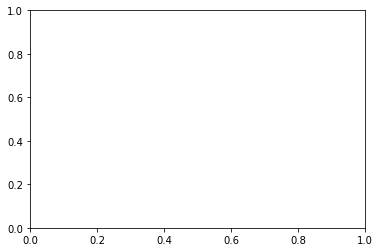

In [26]:
plt.hist(datasets[0].X)


## MACCS features

In [18]:
%%time
output_metrics_maccs = h.deepchem_classification_experiment(
        metrics,
        metric_selector=metric_selector,
        feat_setting='MACCS',
        loader=loader,
        model_setting='MTC',
        dimension=1,
        n_classes=n_classes,
        num_repeats=num_repeats,
        num_epochs=num_epochs,
        split_function=dc.splits.RandomSplitter(),
        split_fraction=split_fraction,
        patience=15,
        metric_labels=metric_labels)

output_metrics_maccs

Metric selected is roc_auc_score
Using dataset selector setting MACCS
!!!!Make this function new for each new dataset!!!!
Training with 203 points
Validation with 204 points
Testing with 1632 points
Total dataset size: 2039
Using multitask classifier model
Step 15 validation: roc_auc_score=0.744935
Step 30 validation: roc_auc_score=0.738182
Step 45 validation: roc_auc_score=0.72013
Step 60 validation: roc_auc_score=0.728961
Step 75 validation: roc_auc_score=0.737792
Step 90 validation: roc_auc_score=0.739091
Step 105 validation: roc_auc_score=0.731169
Step 120 validation: roc_auc_score=0.732857
Step 135 validation: roc_auc_score=0.734675
Step 150 validation: roc_auc_score=0.72987
Step 165 validation: roc_auc_score=0.733117
Step 180 validation: roc_auc_score=0.734026
Step 195 validation: roc_auc_score=0.732078
Step 210 validation: roc_auc_score=0.731948
Step 225 validation: roc_auc_score=0.732987
Step 240 validation: roc_auc_score=0.729188
Step 255 validation: roc_auc_score=0.729091
Ste

Step 1155 validation: roc_auc_score=0.778527
Step 1170 validation: roc_auc_score=0.778222
Step 1185 validation: roc_auc_score=0.777409
Step 1200 validation: roc_auc_score=0.77873
Step 1215 validation: roc_auc_score=0.781237
Step 1230 validation: roc_auc_score=0.780255
Step 1245 validation: roc_auc_score=0.780661
Step 1260 validation: roc_auc_score=0.778324
Step 1275 validation: roc_auc_score=0.778493
Step 1290 validation: roc_auc_score=0.775512
Step 1305 validation: roc_auc_score=0.781237
Step 1320 validation: roc_auc_score=0.780255
Step 1335 validation: roc_auc_score=0.777544
Step 1350 validation: roc_auc_score=0.779204
Step 1365 validation: roc_auc_score=0.775003
Step 1380 validation: roc_auc_score=0.77768
Step 1395 validation: roc_auc_score=0.778527
Step 1410 validation: roc_auc_score=0.778629
Step 1425 validation: roc_auc_score=0.774698
Step 1440 validation: roc_auc_score=0.775478
Step 1455 validation: roc_auc_score=0.775647
Step 1470 validation: roc_auc_score=0.775003
Step 1485 va

,tr_bal_acc,tr_prc_auc,tr_roc_auc,tr_f1,val_bal_acc,val_prc_auc,val_roc_auc,val_f1,te_bal_acc,te_prc_auc,te_roc_auc,te_f1
0,1.0,1.0,1.0,1.0,0.679351,0.889034,0.727208,0.822742,0.688942,0.893021,0.724663,0.846154
1,1.0,1.0,1.0,1.0,0.708633,0.915964,0.775783,0.874214,0.708809,0.911839,0.778124,0.861945
2,1.0,1.0,1.0,1.0,0.715341,0.932947,0.828480,0.870662,0.704250,0.902323,0.770957,0.862400


### graph for 1D features

In [24]:
list_of_data_frames=[output_metrics_ecfp,
    output_metrics_maccs,
    #output_metrics_rdkit,
    #output_metrics_cm_eig,
    #output_metrics_Sm2Img,
    #output_metrics_gc,
    #output_metrics_weave
    #output_metrics_cm,
    output_metrics_tf,
    output_metrics_pca
                    ]

list_of_data_frames_names=["output_metrics_ecfp",
    "output_metrics_maccs",
    #"output_metrics_rdkit",
    #"output_metrics_cm_eig",
    #"output_metrics_Sm2Img",
    #"output_metrics_gc",
    #"output_metrics_weave"
    #"output_metrics_cm",
    "output_metrics_tf",
    "output_metrics_pca"
                          ]

h.method_comparison_plotter(
        list_of_data_frames,
        list_of_columns=['tr_bal_acc', 'tr_prc_auc', 'tr_roc_auc', 'tr_f1',
                                        'val_bal_acc', 'val_prc_auc', 'val_roc_auc', 'val_f1',
                                        'te_bal_acc', 'te_prc_auc', 'te_roc_auc', 'te_f1'],
        color_list=[],
        exclusion_list=[],
        df_exclusion_list=[],
        label_list=['ecfp','maccs','rdkit','cm_eig','tdaf','pca-tdaf'],
        best_con=None,
        best_con_error=None,
        best_gr=None,
        best_gr_error=None,
        x_label='',
        y_label='',
        filename='method_comparison',
        rider='all_data.png', results_dir='')

48


TypeError: 'module' object is not callable

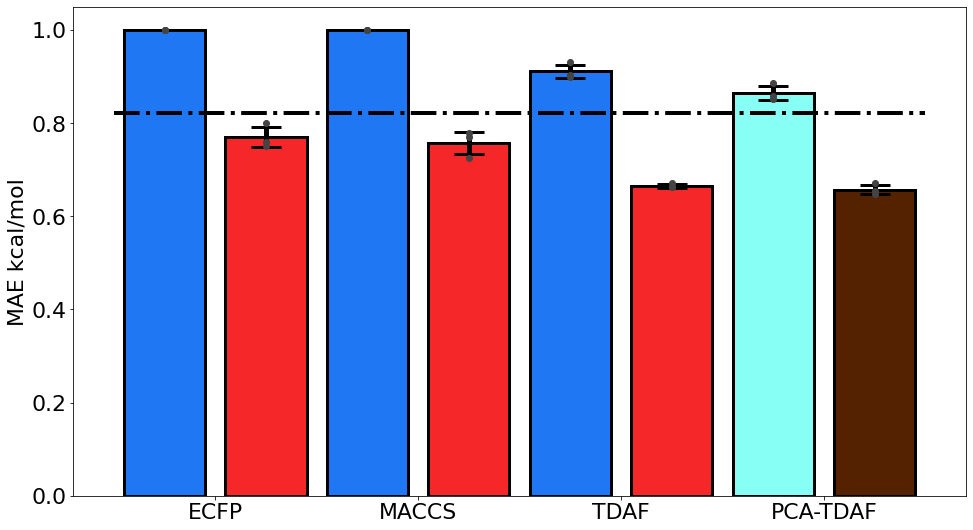

In [28]:


data=[output_metrics_ecfp['tr_roc_auc'],
     output_metrics_ecfp['te_roc_auc'],
     output_metrics_maccs['tr_roc_auc'],
     output_metrics_maccs['te_roc_auc'],
    # output_metrics_rdkit['tr_mae'],
    # output_metrics_rdkit['te_mae'],
    # output_metrics_cm_eig['tr_mae'],
    # output_metrics_cm_eig['te_mae'],
     output_metrics_tf['tr_roc_auc'],
     output_metrics_tf['te_roc_auc'],
     output_metrics_pca['tr_roc_auc'],
     output_metrics_pca['te_roc_auc']]
      
means=[np.mean(x) for x in data]
stds=[np.std(x) for x in data]


x_positions = [x+1 for x in range(len(means))]
plt.figure(figsize=(16, 9))
plt.rcParams.update({'font.size': 22})

plt.bar(x_positions, means, 
        color=["#1f77f4","#f62728",
               "#1f77f4","#f62728",
               "#1f77f4","#f62728",
               "#88fff4","#552200",
               "#5f77f4","#f62788",
               "#5f77f4","#f62788"], 
        edgecolor='k',
        linewidth='3',
        yerr=stds, 
        error_kw=dict(lw=5, capsize=15, capthick=3))
for i in range(len(means)):
    x=data[i]; plt.plot(np.ones(len(x))*(i+1),x,'o',color="#444444")

axes=plt.gca()
#axes.set_ylim([0.5,4.5])
#axes.set_xlim([0.45,4.55])
x_tick_list=[1.5,3.5,5.5,7.5]
plt.xticks(x_tick_list,['ECFP',"MACCS","TDAF","PCA-TDAF"])
plt.plot([0.5,max(x_tick_list)+1],[best_con, best_con],'k',linewidth=4,linestyle='-.')
#plt.plot([0.5,max(x_tick_list)+1],[best_graph, best_graph],'g',linewidth=4,linestyle='-.')

plt.ylabel('MAE kcal/mol')
plt.savefig(os.path.join(dataset_name + "1Donly.png"))

## 2D inputs and graph models

In [9]:
%%time
output_metrics_Sm2Img=h.deepchem_classification_experiment(
        metrics,
        metric_selector=metric_selector,
        feat_setting='Smiles2Img',
        loader=loader,
        model_setting='ChemCeption',
        dimension=2,
        n_classes=n_classes,
        num_repeats=num_repeats,
        num_epochs=num_epochs,
        split_function=dc.splits.RandomSplitter(),
        split_fraction=split_fraction,
        patience=15,
        metric_labels=metric_labels)



output_metrics_Sm2Img.head(3)

Failed to featurize datapoint 59, None. Appending empty array
Exception message: Python argument types in
    rdkit.Chem.rdmolfiles.CanonicalRankAtoms(NoneType)
did not match C++ signature:
    CanonicalRankAtoms(class RDKit::ROMol mol, bool breakTies=True, bool includeChirality=True, bool includeIsotopes=True)
Failed to featurize datapoint 61, None. Appending empty array
Exception message: Python argument types in
    rdkit.Chem.rdmolfiles.CanonicalRankAtoms(NoneType)
did not match C++ signature:
    CanonicalRankAtoms(class RDKit::ROMol mol, bool breakTies=True, bool includeChirality=True, bool includeIsotopes=True)


Metric selected is roc_auc_score
Using dataset selector setting Smiles2Img
!!!!Make this function new for each new dataset!!!!


Failed to featurize datapoint 391, None. Appending empty array
Exception message: Python argument types in
    rdkit.Chem.rdmolfiles.CanonicalRankAtoms(NoneType)
did not match C++ signature:
    CanonicalRankAtoms(class RDKit::ROMol mol, bool breakTies=True, bool includeChirality=True, bool includeIsotopes=True)
Failed to featurize datapoint 614, None. Appending empty array
Exception message: Python argument types in
    rdkit.Chem.rdmolfiles.CanonicalRankAtoms(NoneType)
did not match C++ signature:
    CanonicalRankAtoms(class RDKit::ROMol mol, bool breakTies=True, bool includeChirality=True, bool includeIsotopes=True)
Failed to featurize datapoint 642, None. Appending empty array
Exception message: Python argument types in
    rdkit.Chem.rdmolfiles.CanonicalRankAtoms(NoneType)
did not match C++ signature:
    CanonicalRankAtoms(class RDKit::ROMol mol, bool breakTies=True, bool includeChirality=True, bool includeIsotopes=True)
Failed to featurize datapoint 645, None. Appending empty a

Training with 203 points
Validation with 203 points
Testing with 1627 points
Total dataset size: 2033


ValueError: y must be a class probability matrix with rows summing to 1.

In [11]:
%%time
output_metrics_gc=h.deepchem_classification_experiment(
        metrics,
        metric_selector=metric_selector,
        feat_setting='ConvMol',
        loader=loader,
        model_setting='GraphConv',
        dimension=2,
        n_classes=n_classes,
        num_repeats=num_repeats,
        num_epochs=num_epochs,
        split_function=dc.splits.RandomSplitter(),
        split_fraction=split_fraction,
        patience=15,
        metric_labels=metric_labels)

output_metrics_gc.head(3)

Metric selected is roc_auc_score
Using dataset selector setting ConvMol
!!!!Make this function new for each new dataset!!!!


Failed to featurize datapoint 59, None. Appending empty array
Exception message: Python argument types in
    rdkit.Chem.rdmolfiles.CanonicalRankAtoms(NoneType)
did not match C++ signature:
    CanonicalRankAtoms(class RDKit::ROMol mol, bool breakTies=True, bool includeChirality=True, bool includeIsotopes=True)
Failed to featurize datapoint 61, None. Appending empty array
Exception message: Python argument types in
    rdkit.Chem.rdmolfiles.CanonicalRankAtoms(NoneType)
did not match C++ signature:
    CanonicalRankAtoms(class RDKit::ROMol mol, bool breakTies=True, bool includeChirality=True, bool includeIsotopes=True)
Failed to featurize datapoint 391, None. Appending empty array
Exception message: Python argument types in
    rdkit.Chem.rdmolfiles.CanonicalRankAtoms(NoneType)
did not match C++ signature:
    CanonicalRankAtoms(class RDKit::ROMol mol, bool breakTies=True, bool includeChirality=True, bool includeIsotopes=True)
Failed to featurize datapoint 614, None. Appending empty arr

Training with 203 points
Validation with 204 points
Testing with 1632 points
Total dataset size: 2039
Using GraphConvMol model


C:\Users\ella_\AppData\Roaming\Python\Python37\site-packages\tensorflow\python\framework\indexed_slices.py:450: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/private__graph_conv_keras_model/graph_pool_1/Reshape_14:0", shape=(468,), dtype=int32), values=Tensor("gradient_tape/private__graph_conv_keras_model/graph_pool_1/Reshape_13:0", shape=(468, 64), dtype=float32), dense_shape=Tensor("gradient_tape/private__graph_conv_keras_model/graph_pool_1/Cast_4:0", shape=(2,), dtype=int32))) to a dense Tensor of unknown shape. This may consume a large amount of memory.
  "shape. This may consume a large amount of memory." % value)
C:\Users\ella_\AppData\Roaming\Python\Python37\site-packages\tensorflow\python\framework\indexed_slices.py:450: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/private__graph_conv_keras_model/graph_pool_1/Reshape_17:0", shape=(2132,), dtype=int32), values=Tensor("gradient_tape/private__gr

C:\Users\ella_\AppData\Roaming\Python\Python37\site-packages\tensorflow\python\framework\indexed_slices.py:450: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/private__graph_conv_keras_model/graph_pool_1/Reshape_14:0", shape=(488,), dtype=int32), values=Tensor("gradient_tape/private__graph_conv_keras_model/graph_pool_1/Reshape_13:0", shape=(488, 64), dtype=float32), dense_shape=Tensor("gradient_tape/private__graph_conv_keras_model/graph_pool_1/Cast_4:0", shape=(2,), dtype=int32))) to a dense Tensor of unknown shape. This may consume a large amount of memory.
  "shape. This may consume a large amount of memory." % value)
C:\Users\ella_\AppData\Roaming\Python\Python37\site-packages\tensorflow\python\framework\indexed_slices.py:450: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/private__graph_conv_keras_model/graph_pool_1/Reshape_17:0", shape=(2162,), dtype=int32), values=Tensor("gradient_tape/private__gr

...

C:\Users\ella_\AppData\Roaming\Python\Python37\site-packages\tensorflow\python\framework\indexed_slices.py:450: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/private__graph_conv_keras_model_2/graph_pool_5/Reshape_14:0", shape=(501,), dtype=int32), values=Tensor("gradient_tape/private__graph_conv_keras_model_2/graph_pool_5/Reshape_13:0", shape=(501, 64), dtype=float32), dense_shape=Tensor("gradient_tape/private__graph_conv_keras_model_2/graph_pool_5/Cast_4:0", shape=(2,), dtype=int32))) to a dense Tensor of unknown shape. This may consume a large amount of memory.
  "shape. This may consume a large amount of memory." % value)
C:\Users\ella_\AppData\Roaming\Python\Python37\site-packages\tensorflow\python\framework\indexed_slices.py:450: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/private__graph_conv_keras_model_2/graph_pool_5/Reshape_17:0", shape=(2170,), dtype=int32), values=Tensor("gradient_tape/pri

C:\Users\ella_\AppData\Roaming\Python\Python37\site-packages\tensorflow\python\framework\indexed_slices.py:450: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/private__graph_conv_keras_model_2/graph_pool_5/Reshape_14:0", shape=(545,), dtype=int32), values=Tensor("gradient_tape/private__graph_conv_keras_model_2/graph_pool_5/Reshape_13:0", shape=(545, 64), dtype=float32), dense_shape=Tensor("gradient_tape/private__graph_conv_keras_model_2/graph_pool_5/Cast_4:0", shape=(2,), dtype=int32))) to a dense Tensor of unknown shape. This may consume a large amount of memory.
  "shape. This may consume a large amount of memory." % value)
C:\Users\ella_\AppData\Roaming\Python\Python37\site-packages\tensorflow\python\framework\indexed_slices.py:450: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/private__graph_conv_keras_model_2/graph_pool_5/Reshape_17:0", shape=(2120,), dtype=int32), values=Tensor("gradient_tape/pri

C:\Users\ella_\AppData\Roaming\Python\Python37\site-packages\tensorflow\python\framework\indexed_slices.py:450: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/private__graph_conv_keras_model_2/graph_conv_5/Reshape_11:0", shape=(None,), dtype=int32), values=Tensor("gradient_tape/private__graph_conv_keras_model_2/graph_conv_5/Reshape_10:0", shape=(None, 64), dtype=float32), dense_shape=Tensor("gradient_tape/private__graph_conv_keras_model_2/graph_conv_5/Cast:0", shape=(2,), dtype=int32))) to a dense Tensor of unknown shape. This may consume a large amount of memory.
  "shape. This may consume a large amount of memory." % value)
C:\Users\ella_\AppData\Roaming\Python\Python37\site-packages\tensorflow\python\framework\indexed_slices.py:450: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/private__graph_conv_keras_model_2/graph_conv_5/Reshape_13:0", shape=(None,), dtype=int32), values=Tensor("gradient_tape/pri

Wall time: 40.9 s


,tr_bal_acc,tr_prc_auc,tr_roc_auc,tr_f1,val_bal_acc,val_prc_auc,val_roc_auc,val_f1,te_bal_acc,te_prc_auc,te_roc_auc,te_f1
0,0.528834,0.800954,0.515491,0.394366,0.523026,0.755038,0.522394,0.428571,0.525174,0.780725,0.537894,0.414736
1,0.503378,0.691744,0.443489,0.013423,0.500000,0.739684,0.403354,0.000000,0.496795,0.726791,0.424967,0.007955
2,0.639234,0.903594,0.726264,0.556522,0.538889,0.785714,0.589877,0.434783,0.580945,0.835207,0.642808,0.497156


In [10]:
%%time
output_metrics_weave=h.deepchem_classification_experiment(
        metrics,
        metric_selector=metric_selector,
        feat_setting='Weave',
        loader=loader,
        model_setting='Weave',
        dimension=2,
        n_classes=n_classes,
        num_repeats=num_repeats,
        num_epochs=num_epochs,
        split_function=dc.splits.RandomSplitter(),
        split_fraction=split_fraction,
        patience=15,
        metric_labels=metric_labels)

output_metrics_weave.head(3)

Metric selected is roc_auc_score
Using dataset selector setting Weave
!!!!Make this function new for each new dataset!!!!


Failed to featurize datapoint 59, None. Appending empty array
Exception message: Python argument types in
    rdkit.Chem.rdmolfiles.CanonicalRankAtoms(NoneType)
did not match C++ signature:
    CanonicalRankAtoms(class RDKit::ROMol mol, bool breakTies=True, bool includeChirality=True, bool includeIsotopes=True)
Failed to featurize datapoint 61, None. Appending empty array
Exception message: Python argument types in
    rdkit.Chem.rdmolfiles.CanonicalRankAtoms(NoneType)
did not match C++ signature:
    CanonicalRankAtoms(class RDKit::ROMol mol, bool breakTies=True, bool includeChirality=True, bool includeIsotopes=True)
Failed to featurize datapoint 391, None. Appending empty array
Exception message: Python argument types in
    rdkit.Chem.rdmolfiles.CanonicalRankAtoms(NoneType)
did not match C++ signature:
    CanonicalRankAtoms(class RDKit::ROMol mol, bool breakTies=True, bool includeChirality=True, bool includeIsotopes=True)
Failed to featurize datapoint 614, None. Appending empty arr

Training with 203 points
Validation with 204 points
Testing with 1632 points
Total dataset size: 2039
Using Weave model
Using dataset selector setting Weave
!!!!Make this function new for each new dataset!!!!
Training with 203 points
Validation with 204 points
Testing with 1632 points
Total dataset size: 2039
Using Weave model
Using dataset selector setting Weave
!!!!Make this function new for each new dataset!!!!
Training with 203 points
Validation with 204 points
Testing with 1632 points
Total dataset size: 2039
Using Weave model


Wall time: 1min 31s


,tr_bal_acc,tr_prc_auc,tr_roc_auc,tr_f1,val_bal_acc,val_prc_auc,val_roc_auc,val_f1,te_bal_acc,te_prc_auc,te_roc_auc,te_f1
0,0.5,0.865012,0.641339,0.0,0.5,0.858190,0.715682,0.0,0.500000,0.861583,0.696505,0.000000
1,0.5,0.897629,0.748312,0.0,0.5,0.836761,0.675684,0.0,0.500000,0.860650,0.693538,0.000000
2,0.5,0.852351,0.698824,0.0,0.5,0.899101,0.765372,0.0,0.500399,0.858862,0.692374,0.001596


## Write out data and graphs

In [12]:
list_of_data_frames=[output_metrics_ecfp,
    output_metrics_maccs,
    #output_metrics_rdkit,
    #output_metrics_cm_eig,
    #output_metrics_Sm2Img,
    output_metrics_gc,
    output_metrics_weave
    #output_metrics_cm,
    #output_metrics_tf,
    #output_metrics_pca
                    ]

list_of_data_frames_names=["output_metrics_ecfp",
    "output_metrics_maccs",
    #"output_metrics_rdkit",
    #"output_metrics_cm_eig",
    #"output_metrics_Sm2Img",
    "output_metrics_gc",
    "output_metrics_weave"
    #"output_metrics_cm",
    #"output_metrics_tf",
    #"output_metrics_pca"
                          ]

In [37]:
for i in range(len(list_of_data_frames)):
    list_of_data_frames[i].to_csv(os.path.join(
        results_dir, 
        list_of_data_frames_names[i] + '.csv'))


ValueError: The number of FixedLocator locations (8), usually from a call to set_ticks, does not match the number of ticklabels (6).

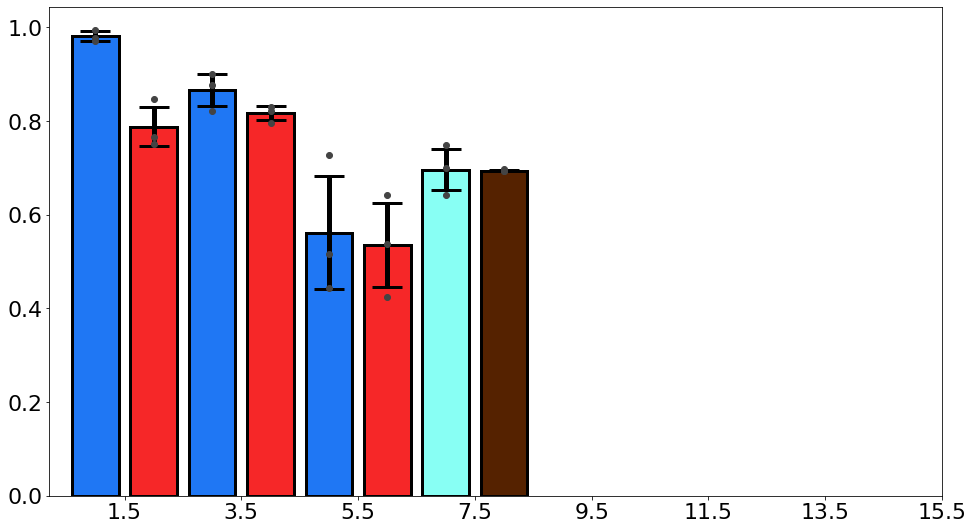

In [13]:
#Best=1.92
#'tr_roc_auc'

data=[output_metrics_ecfp['tr_roc_auc'],
     output_metrics_ecfp['te_roc_auc'],
     output_metrics_maccs['tr_roc_auc'],
     output_metrics_maccs['te_roc_auc'],
     #output_metrics_rdkit['tr_roc_auc'],
     #output_metrics_rdkit['te_roc_auc'],
     #output_metrics_cm_eig['tr_mae'],
     #output_metrics_cm_eig['te_mae'],
     #output_metrics_Sm2Img['tr_roc_auc'],
     #output_metrics_Sm2Img['te_roc_auc'],
     output_metrics_gc['tr_roc_auc'],
     output_metrics_gc['te_roc_auc'],
     output_metrics_weave['tr_roc_auc'],
     output_metrics_weave['te_roc_auc']]
     #output_metrics_cm['tr_mae'],
     #output_metrics_cm['te_mae']]
     #output_metrics_tf['tr_mae'],
     #output_metrics_tf['te_mae'],
     #output_metrics_pca['tr_mae'],
     #output_metrics_pca['te_mae']]
      
means=[np.mean(x) for x in data]
stds=[np.std(x) for x in data]


x_positions = [x+1 for x in range(len(means))]
plt.figure(figsize=(16, 9))
plt.rcParams.update({'font.size': 22})

plt.bar(x_positions, means, 
        color=["#1f77f4","#f62728", # red blue
               "#1f77f4","#f62728",
               "#1f77f4","#f62728",
               "#88fff4","#552200", #brown green
               "#61ff33","#ffb433", # green orange
               "#61ff33","#ffb433",
               "#61ff33","#ffb433",               
               "#88fff4","#552200"], #brown green               
               #"#5f77f4","#f62788", # pink blue
               #"#5f77f4","#f62788"], 
        edgecolor='k',
        linewidth='3',
        yerr=stds, 
        error_kw=dict(lw=5, capsize=15, capthick=3))
for i in range(len(means)):
    x=data[i]; plt.plot(np.ones(len(x))*(i+1),x,'o',color="#444444")


#axes.set_ylim([0.5,4.5])
#axes.set_xlim([0.45,4.55])
x_tick_list=[1.5,3.5,5.5,7.5,9.5,11.5,13.5,15.5]
plt.xticks(x_tick_list,
           ['ECFP',"MACCS","rdkit",
            'Sm2Img', 'GC', 'Weave'], rotation=45)
plt.plot([0.5,max(x_tick_list)+1],[best_con, best_con],'k',linewidth=4,linestyle='-.')
plt.plot([0.5,max(x_tick_list)+1],[best_graph, best_graph],'g',linewidth=4,linestyle='-.')

axes=plt.gca()
plt.ylabel('RMSE kcal/mol')
plt.savefig(os.path.join(results_dir, dataset_name + "control_data.png"))

In [ ]:
#Best=1.92

data=[output_metrics_ecfp['tr_mae'],
     output_metrics_ecfp['te_mae'],
     output_metrics_maccs['tr_mae'],
     output_metrics_maccs['te_mae'],
     output_metrics_rdkit['tr_mae'],
     output_metrics_rdkit['te_mae'],
     output_metrics_cm_eig['tr_mae'],
     output_metrics_cm_eig['te_mae'],
     output_metrics_Sm2Img['tr_mae'],
     output_metrics_Sm2Img['te_mae'],
     output_metrics_gc['tr_mae'],
     output_metrics_gc['te_mae'],
     output_metrics_weave['tr_mae'],
     output_metrics_weave['te_mae'],
     output_metrics_cm['tr_mae'],
     output_metrics_cm['te_mae'],
     output_metrics_tf['tr_mae'],
     output_metrics_tf['te_mae'],
     output_metrics_pca['tr_mae'],
     output_metrics_pca['te_mae']]
      
means=[np.mean(x) for x in data]
stds=[np.std(x) for x in data]


x_positions = [x+1 for x in range(len(means))]
plt.figure(figsize=(16, 9))
plt.rcParams.update({'font.size': 22})

plt.bar(x_positions, means, 
        color=["#1f77f4","#f62728", # red blue
               "#1f77f4","#f62728",
               "#1f77f4","#f62728",
               "#88fff4","#552200", #brown green
               "#61ff33","#ffb433", # green orange
               "#61ff33","#ffb433",
               "#61ff33","#ffb433",               
               "#88fff4","#552200", #brown green               
               "#5f77f4","#f62788", # pink blue
               "#5f77f4","#f62788"], 
        edgecolor='k',
        linewidth='3',
        yerr=stds, 
        error_kw=dict(lw=5, capsize=15, capthick=3))
for i in range(len(means)):
    x=data[i]; plt.plot(np.ones(len(x))*(i+1),x,'o',color="#444444")


#axes.set_ylim([0.5,4.5])
#axes.set_xlim([0.45,4.55])
x_tick_list=[1.5,3.5,5.5,7.5,9.5,11.5,13.5,15.5,17.5,19.5]
plt.xticks(x_tick_list,
           ['ECFP',"MACCS","rdkit","CM_eig",
            'Sm2Img', 'GC', 'Weave', 'CM',
            "TDAF","PCA-TDAF"], roation=45)
plt.plot([0.5,max(x_tick_list)+1],[best_con, best_con],'k',linewidth=4,linestyle='-.')
plt.plot([0.5,max(x_tick_list)+1],[best_graph, best_graph],'g',linewidth=4,linestyle='-.')

axes=plt.gca()
plt.ylabel('MAE kcal/mol')
plt.savefig(os.path.join(results_dir, dataset_name + "all_data.png"))

## stats stuff

import scipy
scipy.stats.ttest_ind(test_scores_CM_eig, test_scores_pca, axis=0, equal_var=True, nan_policy='propagate', alternative='two-sided')

In [ ]:
fh.close()